### Stochastic interpolant demo: unit Gaussian → Gaussian mixture 

We learn a flow map from a simple **base** distribution to a (slightly) more complex
**target** in 1-D.

- **Base** `p_0`: a single unit Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1`: a 2-center Gaussian mixture model.

The `EESI` model trains a drift field `b(t, x)` and score field `s(t, x)` along
the stochastic interpolant

$$x_t = \alpha(t)\,x_0 + \beta(t)\,x_1 + \gamma(t)\,z,\qquad z\sim N(0, I),$$

then estimates the entropy difference using a variety of strategies:
- integrate the learned probability-flow ODE (or reverse-time SDE) from
`t=0` (base) to `t=1` (target), acculumating entropy as either `b * s` or `div(b)` along the paths. 
- directly sample the interpolant from the data, taking the average of `b * s`, `div(b)`, or
`b * (-z/gamma)` — the last one (`method='zdot'`) swaps the learned score for the exact
conditional score the interpolant draw already carries, so it needs neither `net_s` nor autograd

In [1]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
%matplotlib inline

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi import EESI, TimeMLP, GaussianMixture, gmm_ot_couple
from eesi.systems.gmm.train import train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a 16-component Gaussian
mixture built from `eesi.systems.gmm.data.GaussianMixture`, whose weights, means and
full (correlated) covariances are drawn once from a fixed `seed` and then held
constant.

In [2]:
d = 1
# --- base: single 2D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(d, device=device), torch.eye(d, device=device))

# --- target: 16-center Gaussian mixture from eesi.systems.gmm.data.GaussianMixture ---
# Same target used in the FEAT paper
target = GaussianMixture(dim=d,n_mixes=2,loc_scaling=20, mean_shift=18,
                            log_var_scaling=-2,seed=3,device=device)



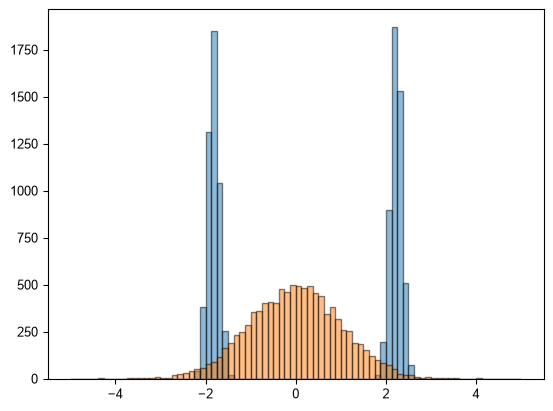

In [3]:
ref_target = target.sample((10000,))
ref_base = base.sample((10000,))

bins = np.linspace(-5,5,81)
plt.hist(ref_target.cpu(),bins=bins,alpha=0.5,edgecolor='k')
plt.hist(ref_base.cpu(),bins=bins,alpha=0.5,edgecolor='k')
plt.show()

### 2. Model & sampler setup

`EESI` wraps two `TimeMLP` fields: the drift `net_b` and the score `net_s`.

- `path="linear"` uses the simple linear interpolant `x_t = (1 - t) * x_0 + t * x_1`.
- `gamma="sqrt"` adds the latent-noise schedule `gamma(t) = gamma_scale * sqrt(t(1-t))`, and the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate).


In [23]:
torch.manual_seed(1)

net_b = TimeMLP(d=d, hidden=32, n_layers=3, activation="silu")
net_s = TimeMLP(d=d, hidden=32, n_layers=3, activation="silu")

model = EESI(
    net_b, net_s,
    d=d,
    path="trig",
    gamma="sin2",
    gamma_scale=0.1
).to(device)

#print(model)
print(sum(p.numel() for p in model.net_b.parameters()))
print(sum(p.numel() for p in model.net_s.parameters()))

#model.net_b.load_state_dict(torch.load('./gmm_b_N16_B1000.pth'))
#model.net_s.load_state_dict(torch.load('./gmm_s_N16_B1000.pth'))

5345
5345


### 3. Training loop

`eesi.systems.gmm.train.train` runs the loop: each iteration draws a fresh batch from
the target `x_1` and from the base `x_0`, couples them by **minibatch optimal transport**
(`eesi.systems.gmm.ot`, squared-Euclidean cost), forms the interpolant internally, and returns the drift/score losses.

In [24]:
# Starting with higher learning rate
model, htot = train(target, steps=10_000, batch=1_000, lr=1e-3, batch_ot=False,
                    device=device, model=model, log_every=100)

"""
# Reduce learning rate slightly and go again
model, hist = train(target, steps=10_000, batch=500, lr=3e-4, batch_ot=True,
                    device=device, model=model, log_every=100)
htot += hist

# Reduce again and let go for a long while
model, hist = train(target, steps=40_000, batch=500, lr=1e-4, batch_ot=True,
                    device=device, model=model, log_every=100)
htot += hist
"""
# grab training logs and save the models
hist_b, hist_s = np.asarray(htot).T
torch.save(model.net_b.state_dict(), './gmm_b.pth')
torch.save(model.net_s.state_dict(), './gmm_s.pth')

  step     0  loss_b   -0.0234  loss_s    0.0126  transport   5.349  (  0.0s)
  step   100  loss_b   -0.3605  loss_s   -0.1294  transport   5.421  (  0.7s)
  step   200  loss_b   -0.5675  loss_s   -0.2138  transport   5.227  (  1.4s)
  step   300  loss_b   -1.0013  loss_s   -0.6804  transport   5.263  (  2.2s)
  step   400  loss_b   -1.0657  loss_s   -1.0494  transport   5.290  (  2.9s)
  step   500  loss_b   -1.1642  loss_s   -1.3802  transport   5.263  (  3.6s)
  step   600  loss_b   -1.3120  loss_s   -1.8076  transport   4.917  (  4.3s)
  step   700  loss_b   -1.3489  loss_s   -2.2168  transport   5.381  (  5.0s)
  step   800  loss_b   -1.3536  loss_s   -2.6070  transport   5.033  (  5.7s)
  step   900  loss_b   -1.3479  loss_s   -2.7371  transport   5.112  (  6.4s)
  step  1000  loss_b   -1.3763  loss_s   -3.0310  transport   5.412  (  7.0s)
  step  1100  loss_b   -1.3742  loss_s   -3.1192  transport   5.238  (  7.7s)
  step  1200  loss_b   -1.3793  loss_s   -3.2859  transport   5.

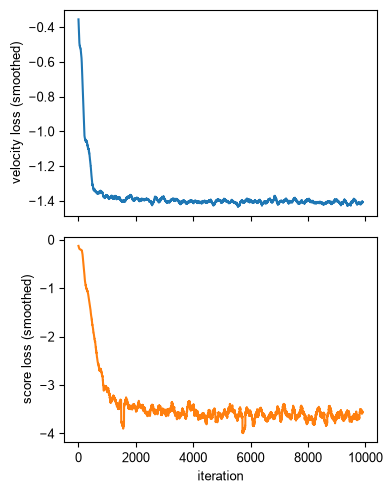

In [25]:
# Training curves (smoothed).
def smooth(v, k=100):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(2,1,sharex=True,figsize=(4,5))
ax[0].plot(smooth(hist_b),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")
#ax[1].set_ylim(-0.9,-0.7)
#ax[0].set_ylim(-1.4,-1)
plt.tight_layout()
plt.show()

### 4. Sampling

Map base samples to the target by integrating ODE/SDE's. `model.sample` with `eps=0.0` integrates the probability-flow **ODE** `dx/dt = b(t, x)` with Heun's method (drift only). Setting `eps > 0.0` integrates the **SDE** with Euler–Maruyama, using both the drift `b` and the learned score `s`.

Since we know the target distribution, we can (roughly) assess the quality of the samples and the anticipated entropy change by calculating the log probability.

In [26]:
# Draw base samples and push them through the model's built-in samplers.
torch.manual_seed(67)
x0 = base.sample((20000,))
x1 = target.sample((20000,))
gen_ode = model.sample(x0, n_steps=100)            # probability-flow ODE (drift only)
gen_sde = model.sample(x0, n_steps=100, eps=0.1)     # reverse-time SDE (drift + score)

# How well do generated samples match the target? (mean log-density)
ref = target.log_prob(x1).mean()
base_ref = base.log_prob(x0).mean()
print(f"mean target log-prob - true target : {ref:+.3f}")
print(f"mean target log-prob - ODE sampler : {target.log_prob(gen_ode).mean():+.3f}")
print(f"mean target log-prob - SDE sampler : {target.log_prob(gen_sde).mean():+.3f}")
print(f"mean base   log-prob - true base   : {base_ref:+.3f}")
print(f"estimated entropy change : {-ref + base_ref:+.3f}")

# predicted change in entropy based on log likelihood from direct sampling of the target
delta_pred = -ref + base_ref
delta_pred = delta_pred.cpu().numpy()


mean target log-prob - true target : -0.043
mean target log-prob - ODE sampler : -0.102
mean target log-prob - SDE sampler : -0.111
mean base   log-prob - true base   : -1.423
estimated entropy change : -1.380


### 5. Entropy along the paths

Including the flag `return_traj = True` in `model.sample` returns the whole integration trajectory. We also track entropy accumulation either by calculating the divergence of the velocity field `entropy="div"` (expensive!) or by taking the inner (dot) product of the velocity and score fields via `entropy="dot"`.

Sampling many trajectories, we get the full distribution of the running entropy accumulation associated with the probability flow.

In [27]:
# Trace the running entropy change along many ODE paths.
torch.manual_seed(100)
batch = 20000
x0 = base.sample((batch,))

# first sample using the dot product formula
traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='dot', return_traj=True)
ts_c = ts.cpu().numpy()
ent_c = ent_traj.cpu().numpy()
dot_mean = ent_c.mean(axis=1)
dot_std = ent_c.std(axis=1)

# first sample using the dot product formula
traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='div', return_traj=True)
ent_c = ent_traj.cpu().numpy()
div_mean = ent_c.mean(axis=1)
div_std = ent_c.std(axis=1)


print(f"observed entropy change         : {delta_pred:+.3f}")
print(f"estimated entropy change (dot)  : {dot_mean[-1]:+.3f} +/- {1.96*dot_std[-1]/np.sqrt(batch):.3f}")
print(f"estimated entropy change (div)  : {div_mean[-1]:+.3f} +/- {1.96*div_std[-1]/np.sqrt(batch):.3f}")


observed entropy change         : -1.380
estimated entropy change (dot)  : -1.668 +/- 0.040
estimated entropy change (div)  : -1.380 +/- 0.010


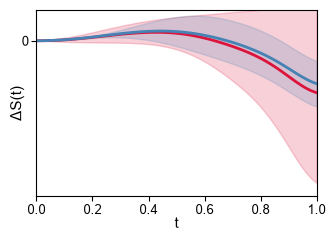

In [28]:
fig, ax = plt.subplots(figsize=(3.375, 2.25))
ax.plot(ts_c, dot_mean, c="crimson", lw=2, label="Dot Product")
ax.fill_between(ts_c, dot_mean - dot_std, dot_mean + dot_std, color='crimson', alpha=0.2)
ax.plot(ts_c, div_mean, c="steelblue", lw=2, label="Divergence")
ax.fill_between(ts_c, div_mean - div_std, div_mean + div_std, color='steelblue', alpha=0.2)

ax.set_xlabel("t",labelpad=0,fontsize=11); ax.set_ylabel(r"$\Delta$S(t)",labelpad=-3,fontsize=11)
ax.set_yticks([0,-40,-80,-120],labels=["0","-40","-80","-120"])
ax.set_yticks([-20,-60,-100,-140],labels=None,minor=True)
ax.tick_params(pad=2)
ax.set_ylim(-5,1)
ax.set_xlim(0,1)
#ax.grid(True,which='both',axis='both',color='gray', 
#        linestyle='--', linewidth=0.5, alpha=0.7)

dsdt_dot = np.diff(dot_mean)
dsdt_div = np.diff(div_mean)
err = dsdt_dot/dsdt_div - 1
t_diff = ts_c[:-1] + 0.5*(ts_c[1]-ts_c[0])

#ins_ax = ax.inset_axes([.24, .16, 0.4, 0.4])
#ins_ax.axhline(0,-1,1,color='k',linestyle=':',lw=1.5)
#ins_ax.plot(t_diff, err, c="orange", lw=2, label="Difference")
#ins_ax.set_xlim(0,1)
#ins_ax.set_ylim(-0.3,0.3)
#ins_ax.set_ylabel("Relative Error",fontsize=9,labelpad=1)
#ins_ax.set_yticks([-0.2,0,0.2],labels=["-0.2","0","0.2"],fontsize=8)
#ins_ax.set_xticks([0,0.5,1],labels=["0","0.5","1"],fontsize=8)
#ins_ax.set_xticks([0.25,0.75],labels=None,minor=True)
#ins_ax.tick_params(pad=1)


plt.subplots_adjust(0.14,0.15,0.97,0.98)

#plt.savefig("gmm.eps",dpi=600)
#plt.savefig("gmm.pdf",dpi=600)
#plt.savefig("gmm.png",dpi=600)
plt.show()


### 6. Generation-Free Entropy Estimate

In [29]:
torch.manual_seed(35)
# IMPORTANT: this must be the same as the batch size used for 
# training if minibatch OT was used. The use of OT effectively alters
# the joint distribution of (x_0,x_1), which affects the interpolant 
# time marginals. To sample them properly, you must do the same coupling!
batch = 500


means = []
for n in range(200):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, method='dot')   # b*s formulation
    means.append(ent.mean().cpu().numpy())
print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


-1.3799487
-1.6684391
0.2117797
0.20905879


In [30]:
torch.manual_seed(35)
# IMPORTANT: this must be the same as the batch size used for 
# training if minibatch OT was used. The use of OT effectively alters
# the joint distribution of (x_0,x_1), which affects the interpolant 
# time marginals. To sample them properly, you must do the same coupling!
batch = 500


means = []
for n in range(200):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, method='zdot')   # b*z formulation
    means.append(ent.mean().cpu().numpy())
print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


-1.3799487
-1.4098271
0.2119567
0.021651803


In [31]:
torch.manual_seed(35)
# IMPORTANT: this must be the same as the batch size used for 
# training if minibatch OT was used. The use of OT effectively alters
# the joint distribution of (x_0,x_1), which affects the interpolant 
# time marginals. To sample them properly, you must do the same coupling!
batch = 500


means = []
for n in range(200):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, method='bdot')   # b*z formulation
    means.append(ent.mean().cpu().numpy())
print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


-1.3799487
-1.6633459
0.25430208
0.20536792


In [32]:
torch.manual_seed(36)
batch = 500
x1 = target.sample((batch,))

means = []
for n in range(200):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate(x1, x0, "div")   # div(b) formulation
    means.append(ent.mean().detach().cpu().numpy())
print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


-1.3799487
-1.3910443
0.123052016
0.008040533


The `dot` estimate above is badly biased (~-72%) while `div` is not: the learned score is
the weak link, not the velocity. `method='zdot'` keeps the `b * s` form but replaces the
*learned* score with the **exact conditional score** `-z/gamma(t)` that the interpolant draw
already carries. That is unbiased for the true score by the tower property,
`grad log p_t(x) = E[-z/gamma | x_t = x]`, since `b` sees the draw only through `x_t` — so
whatever `net_s` failed to learn drops out.

The `1/gamma` diverges at both endpoints, so the estimate is the average of the antithetic
`+z` / `-z` pair, which reduces to `z.(b(x_t^+) - b(x_t^-)) / (2 gamma) -> z^T (grad b) z` as
`gamma -> 0`: a central-difference Hutchinson trace with step `gamma(t)`. It needs only
`net_b` and no autograd at all — cheaper than `div`, and unbiased where `dot` is not.

(The flip side of that finite difference: at very small `gamma` the two branches differ in the
last few significant digits. `gamma="sqrt"` with `gamma_scale=0.2` floors `gamma` at ~2e-4 here,
so float32 is fine; with `gamma="quad"` and the default `eps=1e-6` it would not be — build the
model with a larger `eps` (~1e-3) in that case.)

In [56]:
torch.manual_seed(37)
batch = 500   # same caveat as the 'dot' cell: match the training batch if minibatch OT was used

means = []
for n in range(200):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, method='zdot')   # b*(-z/gamma) formulation
    means.append(ent.mean().cpu().numpy())
print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)

-1.3799487
-1.3885792
0.16473502
0.0062542283


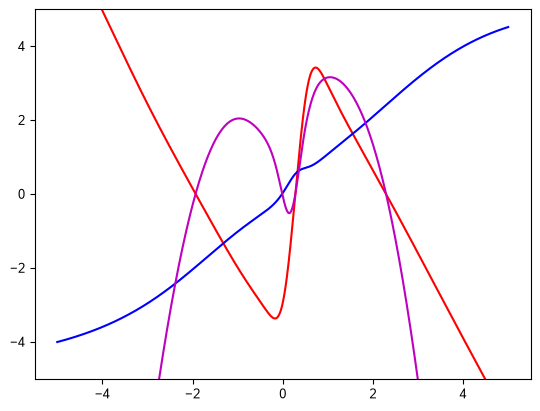

In [30]:
x = torch.linspace(-5,5,1001,device=device)
x = x.unsqueeze(-1)
t = 1.0*torch.ones_like(x)
s_plot = model.net_s(t,x)
b_plot = model.net_b(t,x)
plt.plot(x.cpu(),s_plot.detach().cpu(),'-r')
plt.plot(x.cpu(),b_plot.detach().cpu(),'-b')
plt.plot(x.cpu(),b_plot.detach().cpu()*s_plot.detach().cpu(),'-m')
plt.ylim(-5,5)
plt.show()


In [57]:
torch.manual_seed(37)
batch = 500   # same caveat as the 'dot' cell: match the training batch if minibatch OT was used

ent_zdot = []
ent_div = []
for n in range(200):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, method='zdot')   # b*(-z/gamma) formulation
    ent_zdot.append(ent.cpu().numpy())
    ent = model.entropy_estimate(x1, x0, method='div')   # b*(-z/gamma) formulation
    ent_div.append(ent.cpu().numpy())

eesi_zdot = np.array(ent_zdot).flatten()
eesi_div = np.array(ent_div).flatten()


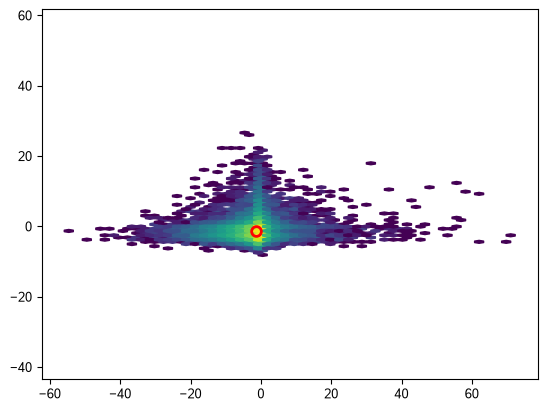

In [60]:
plt.hexbin(eesi_zdot,eesi_div,bins='log',gridsize=50)
plt.plot(np.mean(eesi_zdot),np.mean(eesi_div),'ro',mew=2,mfc='none',ms=7)
plt.axis('equal')
plt.show()






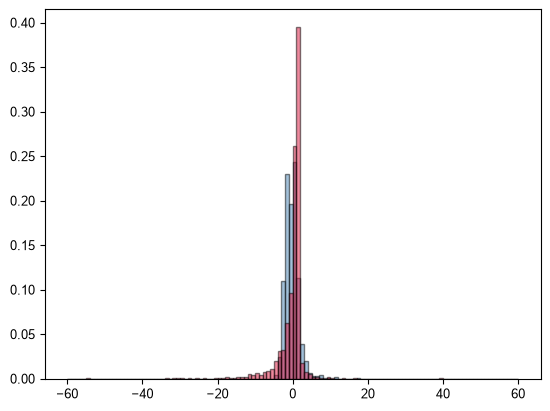

In [67]:
thresh = -1.3
edges = np.linspace(-60,60,121)
idx = np.where(np.isclose(eesi_zdot,thresh,rtol=0.05))[0]
plt.hist(eesi_div[idx]-thresh,bins=edges,edgecolor='black',density=True,color='steelblue',alpha=0.5)
#plt.yscale('log')
idx = np.where(np.isclose(eesi_div,thresh,rtol=0.05))[0]
plt.hist(eesi_zdot[idx]-thresh,bins=edges,edgecolor='black',density=True,color='crimson',alpha=0.5)

plt.show()





In [65]:
import scipy.stats
print(scipy.stats.skew(eesi_div))
print(scipy.stats.skew(eesi_zdot))

2.2454407
-0.5864107


In [69]:
eesi_div.var()

np.float32(4.245816)

In [70]:
eesi_zdot.var()

np.float32(14.361403)